In [1]:
%matplotlib notebook

import numpy as np
from scipy.signal import medfilt
from scipy.ndimage import gaussian_filter1d
from matplotlib import pyplot as plt

import pandas as pd
import re
from glob import glob

In [2]:
mutants = ['wt', 'N214A', 'Q256A', 'S284A']

In [3]:
def load_uv_data(filename):

    data = []
    
    with open(filename, 'rb') as f:
        for i,line in enumerate(f):
            d = line.split()[:2]
            if i > 3 and d:            
                data.append([float(x) for x in d])
            
    return np.array(data)


def conc_from_title(filename):
    
    dec = re.search('_(\d+)_(\d+)uM', filename)
    ndc = re.search('_(\d+)uM', filename)
    
    if dec:
        conc = float(dec.groups()[0] + '.' + dec.groups()[1])
    elif ndc:
        conc = float(ndc.groups()[0])
    else:
        raise RuntimeError('no regex match')
            
    return conc

In [4]:
all_data = {}

for mutant in mutants:
    
    data = {}
    for fn in glob('./data/*{}*.csv'.format(mutant)):

        c = conc_from_title(fn)
        d = load_uv_data(fn)
        data[c] = d
        
    all_data[mutant] = data

In [9]:
# peak positions

concs = sorted(all_data['wt'].keys())

p1 = 0.49
p2 = 0.545

p1_amp = np.zeros([len(mutants), len(concs)])
p2_amp = np.zeros([len(mutants), len(concs)])

<IPython.core.display.Javascript object>


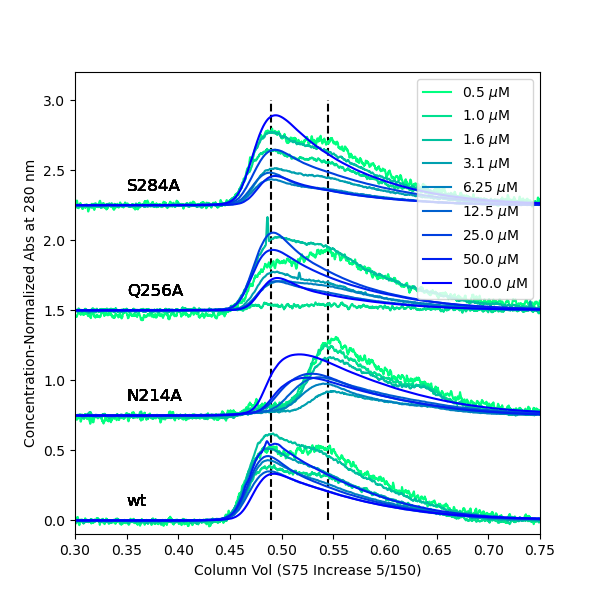

In [10]:
plt.figure(figsize=(6,6))

colors = plt.cm.winter(np.linspace(1,0,len(concs)))

for im,m in enumerate(mutants):
    
    offset = im * 0.75
    
    data = all_data[m]

    for i,c in enumerate(concs):
        CV = data[c][:,0] / 3.0
        UV = (data[c][:,1] - np.median(data[c][:,1])) / c
        plt.plot(CV, UV + offset, color=colors[i])
        plt.text(0.35, 0.1 + offset, m, fontsize=12, fontweight=10)
        
        p1_amp[im,i] = UV[ np.argmin(np.abs(CV - p1)) ]
        p2_amp[im,i] = UV[ np.argmin(np.abs(CV - p2)) ]
        
plt.xlim([0.30, 0.75])
plt.ylim([-0.1, 3.2])
plt.xlabel('Column Vol (S75 Increase 5/150)')
plt.ylabel('Concentration-Normalized Abs at 280 nm')

plt.vlines([p1, p2], 0.0, 3.0, 'k', linestyles='dashed')
plt.legend(['{} $\mu$M'.format(c) for c in concs], loc=1, title='')

plt.show()

<IPython.core.display.Javascript object>


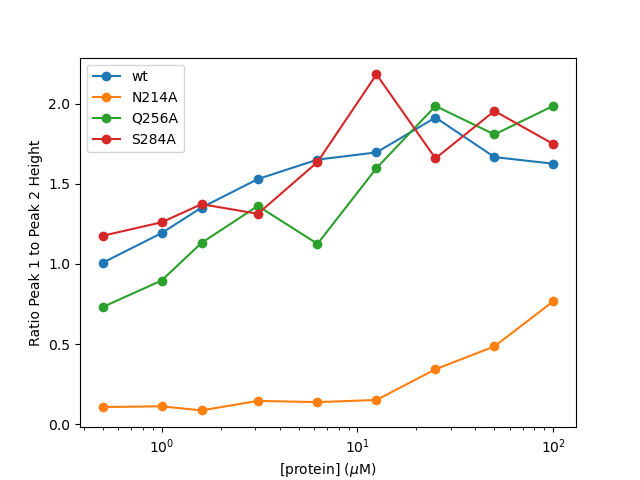

In [11]:
plt.figure()
plt.plot(concs, p1_amp.T / p2_amp.T, '-o')
plt.xlabel('[protein] ($\mu$M)')
plt.ylabel('Ratio Peak 1 to Peak 2 Height')
plt.legend(mutants)
plt.xscale('log')
plt.show()